In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# 1. データの読み込み（パスは環境に合わせて調整してください）
# ※ここでは直下に train.csv がある前提にしています
train = pd.read_csv('../../data/raw/train.csv')

In [10]:
# 2. グラフの日本語文字化け対策（必要に応じて設定してください）
plt.rcParams['font.family'] = 'MS Gothic' # Windows用 (Macの場合は 'AppleGothic')

In [11]:
# 3. 対象カラムの選定（id, CustomerId, Surname, 正解ラベル 以外）
target_cols = [
    'CreditScore', 'Geography', 'Gender', 'Age', 
    'Tenure', 'Balance', 'NumOfProducts', 
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]


=== Geography の解約率クロス集計 ===
Exited           0.0        1.0
Geography                      
France     84.531542  15.468458
Germany    58.345588  41.654412
Spain      83.672193  16.327807

=== Gender の解約率クロス集計 ===
Exited        0.0        1.0
Gender                      
Female  71.578467  28.421533
Male    85.861823  14.138177

=== NumOfProducts の解約率クロス集計 ===
Exited               0.0        1.0
NumOfProducts                      
1.0            61.034107  38.965893
2.0            95.905663   4.094337
3.0             4.639175  95.360825
4.0             3.125000  96.875000

=== HasCrCard の解約率クロス集計 ===
Exited           0.0        1.0
HasCrCard                      
0.0        79.209107  20.790893
1.0        79.711885  20.288115

=== IsActiveMember の解約率クロス集計 ===
Exited                0.0        1.0
IsActiveMember                      
0.0             71.424837  28.575163
1.0             88.108844  11.891156


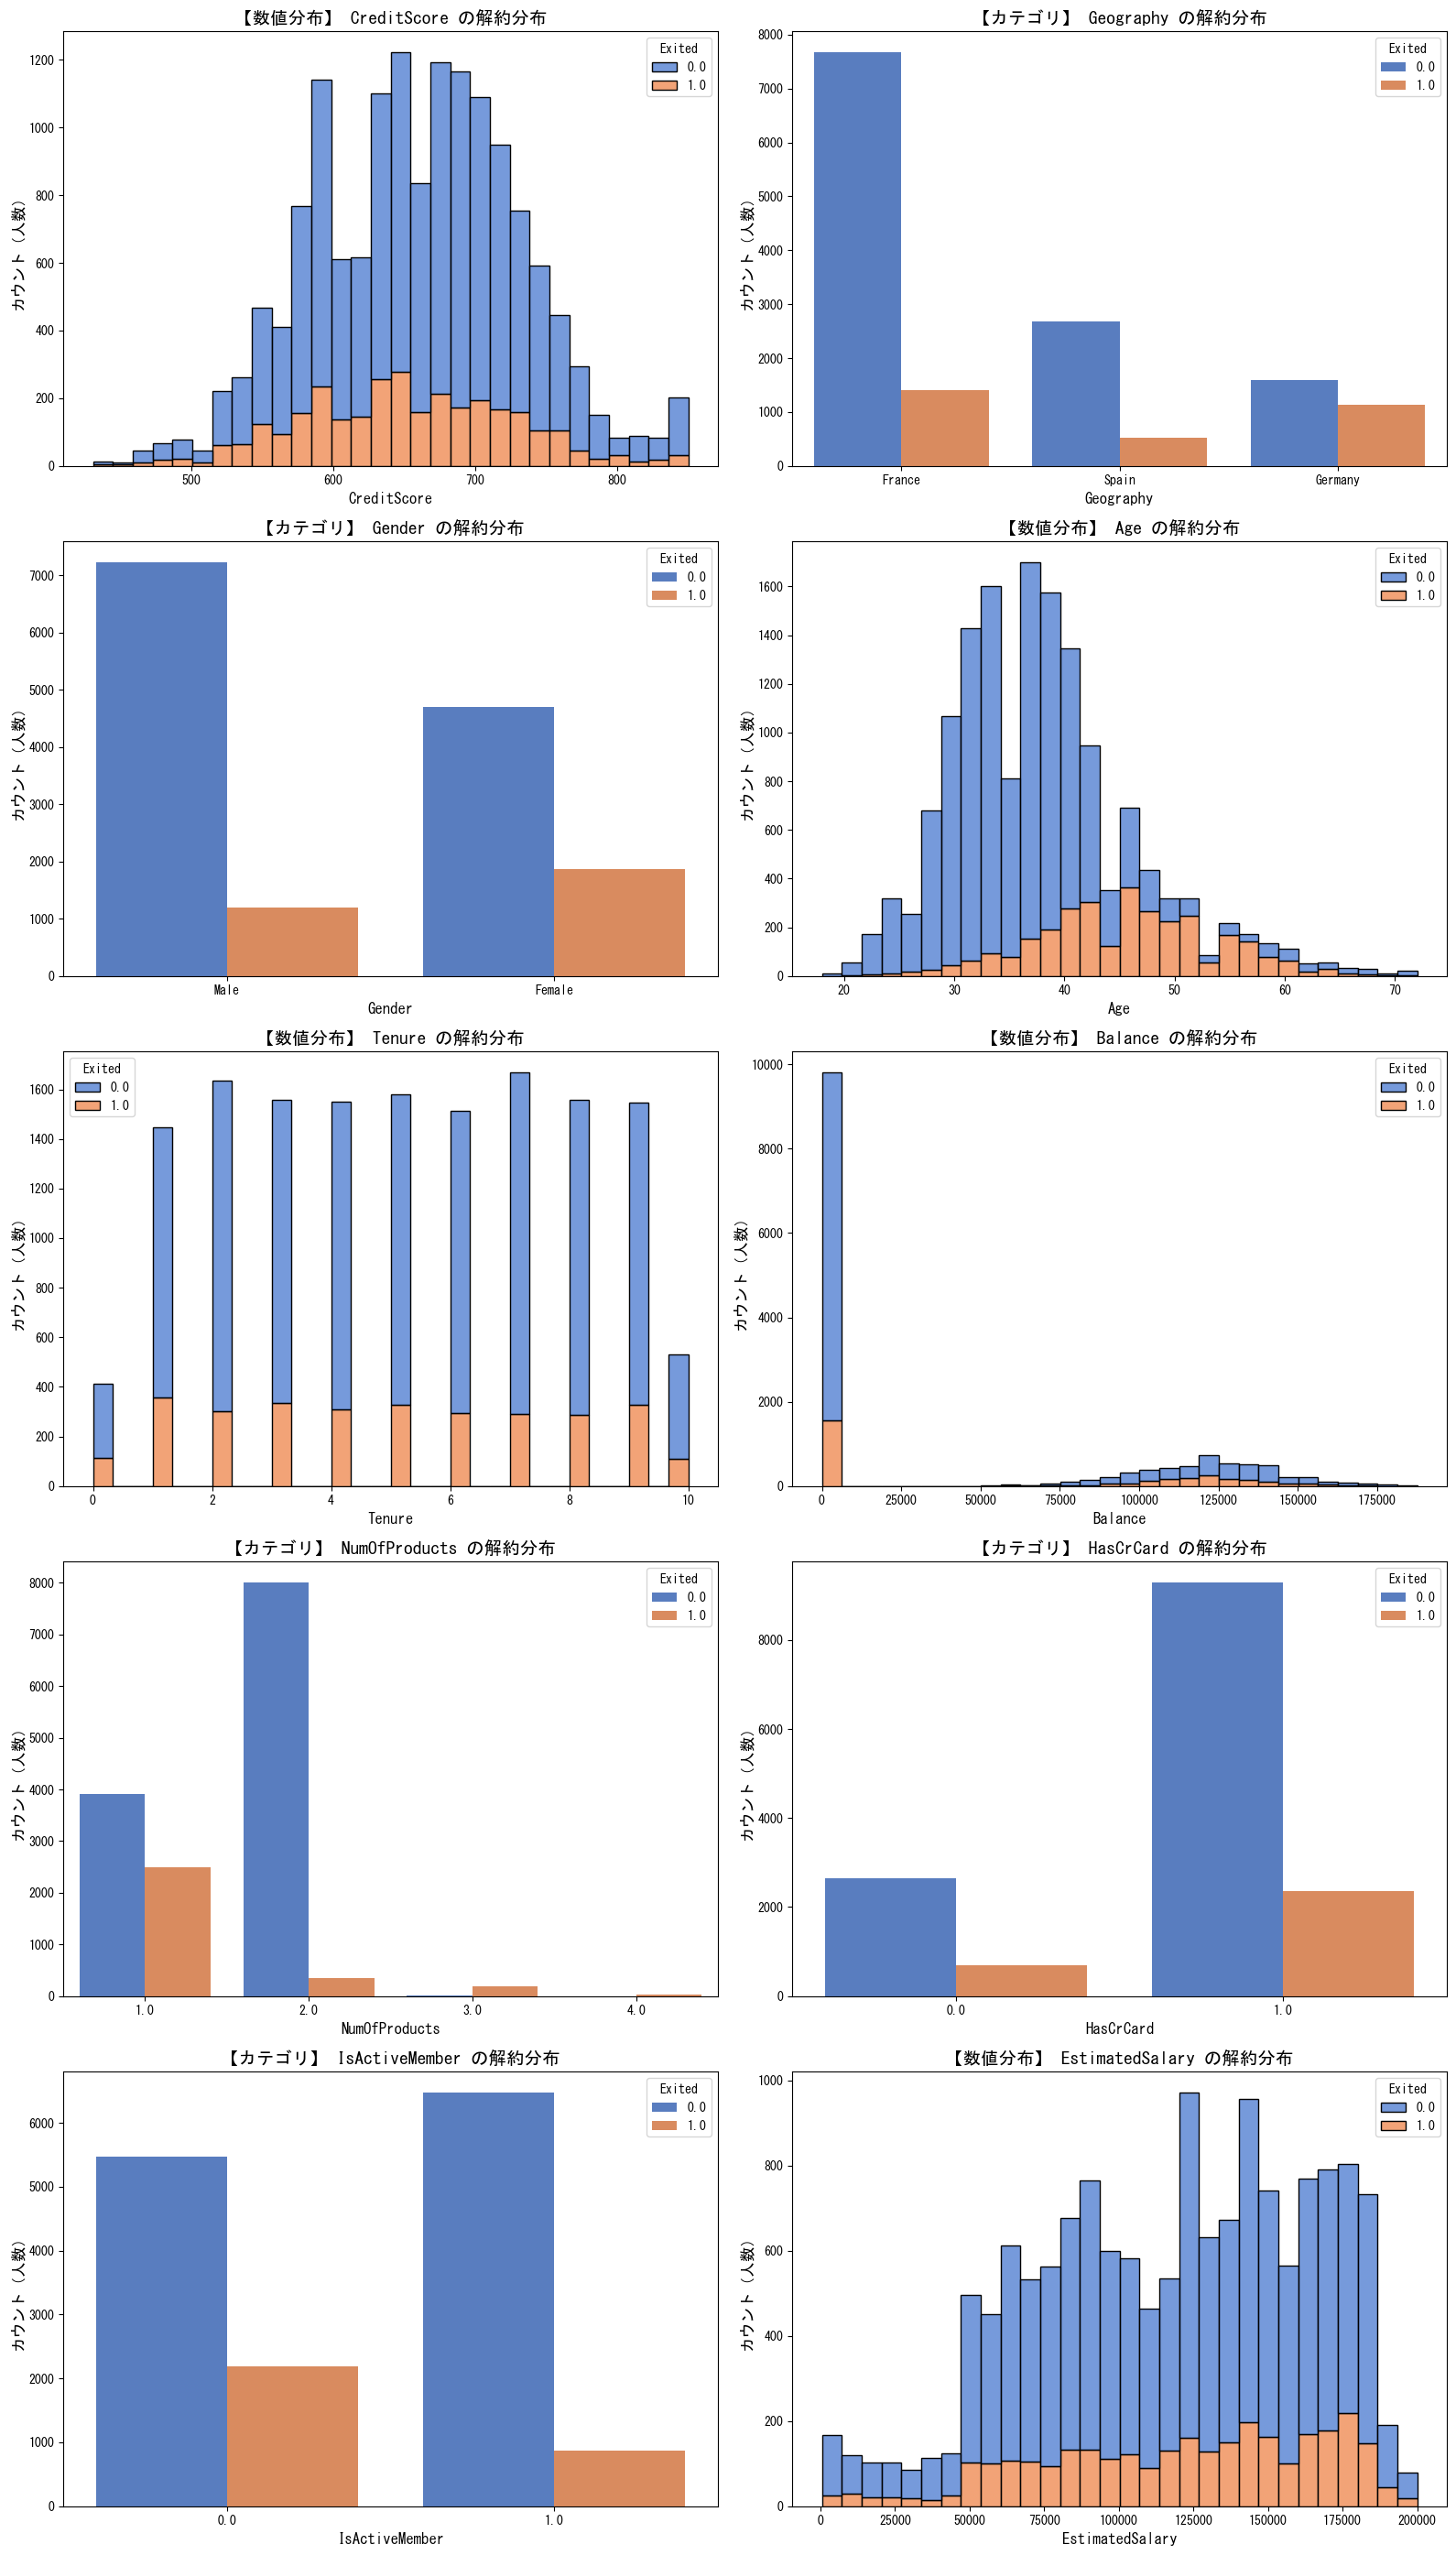

In [15]:

# 4. グラフの配置設定（5行2列で10個のカラムを並べる）
fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.flatten() # 2次元の配列を1次元に平坦化してループしやすくする

# 5. ループ処理で各カラムの分布を描画
for i, col in enumerate(target_cols):
    
    # 種類の数が少ないもの（国、性別、フラグ系、製品数など）は【カウントプロット】
    if train[col].nunique() <= 5:
        sns.countplot(
            data=train, 
            x=col, 
            hue='Exited', 
            ax=axes[i], 
            palette='muted'
        )
        axes[i].set_title(f'【カテゴリ】 {col} の解約分布', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('カウント（人数）', fontsize=12)
        
        # 数値としての割合もターミナル（ログ）に出力する
        print(f"\n=== {col} の解約率クロス集計 ===")
        print(pd.crosstab(train[col], train['Exited'], normalize='index') * 100)
        
    # 種類の数が多い連続値（年齢、残高、年収、スコア）は【ヒストグラム】
    else:
        sns.histplot(
            data=train, 
            x=col, 
            hue='Exited', 
            multiple='stack', # 解約と継続を積み上げる形式
            ax=axes[i], 
            bins=30, 
            palette='muted'
        )
        axes[i].set_title(f'【数値分布】 {col} の解約分布', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('カウント（人数）', fontsize=12)
# レイアウトを綺麗に整えて表示
plt.tight_layout()
plt.show()

# グラフを画像として保存したい場合（コメントアウトを解除してください）
# plt.savefig('all_columns_distribution.png', dpi=100)